# 05 · First fit: what the lab data can and cannot say about the models

The first optimisation of the kinetic models against the lab NMR observables. It is **diagnostic**: for every candidate structure it gives a best fit with the misfit per observation, and it says which parameters the data determine, which results change with the unknown mixing times, which sample drives each value, and which structures the data cannot tell apart. It is not a final calibration.

**This notebook only loads and shows results.** They are computed by `scripts/run_fit.py`, stage by stage (`registered`, `recovery`, `baselines`, `extended`, `refit`, `night`, `traces`, `predictions`), into `notebooks/results/05/` (not stored in the repository). The science is in `kinetics/fitting/` (`residuals.py`, `candidates.py`, `estimation.py`), the figures in `demo/fit_plots.py`. The plan and its reasoning are in [docs/plan-first_fit.md](../docs/plan-first_fit.md).

**Rules fixed before any fit**

| Rule | Value |
|---|---|
| Scenarios of the unknown ages (time from mixing to a sample's first spectrum) | `short` 1 h, `middle` 1 day, `long` 7 days for every sample; `free`: each age between 1 h and 7 days, chosen to favour the model |
| Fit rule | a structure fits a scenario if no standardised residual exceeds 3 in absolute value; the pull of a freed reaction energy from its computed value counts as a residual |
| First consistent parameter set | the smallest structure that fits; a common-age scenario takes precedence over free ages. With free ages only, the set is reported and no model is registered |
| Error of a share | noise ⊕ baseline spread ⊕ floor (³¹P: larger of 0.01 and 5 %; ¹³C: larger of 0.03 and 15 %) |
| Activation entropy | ΔS‡ = 0 in every fit; −150 to +50 J mol⁻¹ K⁻¹ for the protocol band |

**Candidate structures** (simplest first)

| Structure | Free | What it assumes |
|---|---|---|
| M0-BEP | 1 | one barrier for all nine reactions, capped BEP: the structure of `peter_reference` |
| M0-Marcus | 1 | one barrier for all nine reactions, Marcus |
| M1 | 4 | one Marcus barrier per family: the structure of `level1` |
| M1-split | 5 | M1 with R1 separate from R2 and R3 |
| M3 | 8 | M1 with ΔG_rxn of R1–R4 free, held to the computed values by their covariance |
| M3-split | 9 | M1-split with the same freed energies |

**Assumptions**
- Thermochemistry and barrier relations as in notebook 01; EC/DEC samples simulated in EC at 7.1 M (buffered), one phase.
- The observables file was **built from the share tables exported by notebook 03**, not from the raw spectra; the heating steps of the 2 % sample carry assumed clock times and minimum durations (§1).
- The 0.5 % water sample may hold LiPF₆ (notebook 04, Appendix A). It is kept in the fit and the fit without it is in §5.3.
- Every sample starts from its recipe alone. §4.3 shows what a trace of TMSOH at mixing changes.

**Classification:** CONFIDENTIAL (see CLASSIFICATION.md) · **Source:** Y. Alcaraz Galván; outputs computed from P. Broqvist, Tank dataset snapshot (unpublished) and N. Gogoi, raw lab NMR spectra 2022–2023 (unpublished); Gogoi et al., J. Phys. Chem. C 2024, 128, 1654 (published). Do not commit this notebook with its outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics.data import calculate_replicate_scatter, describe_lab_observables, load_lab_observables, tabulate_observable_shares
from kinetics.fitting import FIT_STRUCTURES, build_sample_set, load_fit_result
from demo import fit_plots, style, tables

style.apply_style()
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200)

RESULTS = REPO / 'notebooks' / 'results' / '05'      # written by scripts/run_fit.py
SCENARIOS = ('short', 'middle', 'long', 'free')
STRUCTURES = list(FIT_STRUCTURES)
MAIN = 'M3-split'                                    # the largest structure: every other one is a special case of it


FITTING = ('middle', 'long', 'free')                 # the scenarios the largest structure fits (§4)


def read(name):
    return pd.read_csv(RESULTS / name)


def show_M(value):
    # A concentration in mol/L as text: 1e-6 becomes '1 µM'
    if not value > 0:
        return 'none'
    return next(f'{value / scale:g} {unit}' for unit, scale in (('mM', 1e-3), ('µM', 1e-6), ('nM', 1e-9)) if value >= 0.999 * scale)

## 1. The data a fit reads

`data/lab_observables.json` holds, per sample, the recipe, what is known of its history and the area shares of each quantitative spectrum with their two measured uncertainties. `build_sample_set` adds the declared error floor and the scenario.

In [2]:
observables = load_lab_observables()
print('built from:', observables['_meta']['built_from'])
display(describe_lab_observables(observables))

shares = tabulate_observable_shares(observables)
shares['value'] = [f"{s:.3f} ± {np.hypot(n, b):.3f}" for s, n, b in zip(shares['share'], shares['sigma_noise'], shares['sigma_baseline'])]
display(shares.pivot_table(index=['sample', 't_since_first_h', 'temperature_C'], columns='window', values='value', aggfunc='first', sort=False)
        .rename_axis(columns='share ± (noise ⊕ baseline)'))

scatter = calculate_replicate_scatter(observables, '2 % H2O')
print(f"Six spectra of the 2 % sample: χ² {scatter['chi2']:.1f} about their mean on {scatter['dof']} degrees of freedom "
      f"(noise only); Birge ratio {scatter['birge']:.2f}")
display(scatter['per_window'].round(4))

fit_set = build_sample_set(observables, 'middle')
pd.DataFrame([{'sample': s['name'], 'values': 1 if s['kind'] == 'paper' else s['measured'].size,
               'treated as': 'one-sided limit' if s['kind'] == 'paper' else
               f"one composition + {len(s['t_spec_s']) - 1} drift measurements" if s['replicate'] else 'independent spectra',
               'independent error × Birge': s.get('birge', np.nan)} for s in fit_set]).set_index('sample')

built from: notebooks/results/03/lab_shares_31P.csv and lab_shares_13C.csv (area shares exported by 03_feasible_region.ipynb); heating episodes transcribed from notebooks 03 and 04. NOT rebuilt from the raw spectra


,role,campaign,spectra,solutes at t = 0,T of the spectra (°C),time since first spectrum (h),before the first spectrum,heated after the first spectrum,flags
0.5 % H2O,fit,2022,1 31P,"TMSPA 149 mM, H2O 263 mM",22,18.86,unknown (age),—,2
2 % H2O,fit,2022,6 31P,"TMSPA 149 mM, H2O 1052 mM","22, 23",0.08 to 145.1,unknown (age),"30 °C × 18 min, 40 °C × 18 min, 50 °C × 18 min, 60 °C × 18 min, 70 °C × 18 min, 80 °C × 18 min",0
TMSPa + TMSOH (A),fit,2023,1 31P,"TMSPA 149 mM, TMSOH 180 mM",22,0.06,unknown (age),—,1
TMSPa + TMSOH (B),hold_out,2023,1 31P,"TMSPA 149 mM, TMSOH 180 mM",22,2.00,unknown (age),—,1
TMSPa alone,check,2023,2 31P,TMSPA 149 mM,22,0.05 to 242.9,unknown (age),—,1
"TMSOH, probe",fit,2022,3 13C,TMSOH 450 mM,"22, 23, 80",0.22 to 144.0,unknown (age),80 °C × 9 min,1
"TMSOH, glovebox",fit,2022,1 13C,TMSOH 450 mM,22,0.09,80 °C × 8 h,—,3


share ± (noise ⊕ baseline)                                TMSPA  \
sample            t_since_first_h temperature_C                   
0.5 % H2O         18.863611       22.3            0.930 ± 0.019   
2 % H2O           0.077222        22.5           -0.001 ± 0.028   
                  33.086389       22.3           -0.010 ± 0.013   
                  72.078611       22.4            0.000 ± 0.013   
                  96.083056       22.5            0.009 ± 0.014   
                  120.084722      22.8           -0.002 ± 0.013   
                  145.094722      22.9           -0.001 ± 0.012   
TMSPa + TMSOH (A) 0.061389        21.7            0.105 ± 0.043   
TMSPa + TMSOH (B) 2.002500        21.9            0.083 ± 0.102   
TMSPa alone       0.052222        21.8            0.807 ± 0.051   
                  242.878056      21.7            0.232 ± 0.050   
TMSOH, probe      0.220278        23.0                      NaN   
                  138.711389      80.0                      NaN   
                  144.046667      22.3                      NaN   
TMSOH, glovebox   0.085556        22.3                      NaN   

share ± (noise ⊕ baseline)                               BMSPA  \
sample            t_since_first_h temperature_C                  
0.5 % H2O         18.863611       22.3           0.060 ± 0.009   
2 % H2O           0.077222        22.5           0.047 ± 0.032   
                  33.086389       22.3           0.033 ± 0.006   
                  72.078611       22.4           0.033 ± 0.010   
                  96.083056       22.5           0.036 ± 0.004   
                  120.084722      22.8           0.040 ± 0.004   
                  145.094722      22.9           0.042 ± 0.008   
TMSPa + TMSOH (A) 0.061389        21.7           0.687 ± 0.056   
TMSPa + TMSOH (B) 2.002500        21.9           0.911 ± 0.176   
TMSPa alone       0.052222        21.8           0.118 ± 0.049   
                  242.878056      21.7           0.688 ± 0.048   
TMSOH, probe      0.220278        23.0                     NaN   
                  138.711389      80.0                     NaN   
                  144.046667      22.3                     NaN   
TMSOH, glovebox   0.085556        22.3                     NaN   

share ± (noise ⊕ baseline)                                MMSPA  \
sample            t_since_first_h temperature_C                   
0.5 % H2O         18.863611       22.3           -0.013 ± 0.013   
2 % H2O           0.077222        22.5            0.311 ± 0.012   
                  33.086389       22.3            0.319 ± 0.011   
                  72.078611       22.4            0.315 ± 0.014   
                  96.083056       22.5            0.316 ± 0.012   
                  120.084722      22.8            0.315 ± 0.011   
                  145.094722      22.9            0.314 ± 0.012   
TMSPa + TMSOH (A) 0.061389        21.7            0.194 ± 0.042   
TMSPa + TMSOH (B) 2.002500        21.9            0.008 ± 0.077   
TMSPa alone       0.052222        21.8            0.050 ± 0.043   
                  242.878056      21.7            0.042 ± 0.044   
TMSOH, probe      0.220278        23.0                      NaN   
                  138.711389      80.0                      NaN   
                  144.046667      22.3                      NaN   
TMSOH, glovebox   0.085556        22.3                      NaN   

share ± (noise ⊕ baseline)                               H3PO4          TMSOH  \
sample            t_since_first_h temperature_C                                 
0.5 % H2O         18.863611       22.3           0.023 ± 0.028            NaN   
2 % H2O           0.077222        22.5           0.665 ± 0.012            NaN   
                  33.086389       22.3           0.667 ± 0.007            NaN   
                  72.078611       22.4           0.667 ± 0.011            NaN   
                  96.083056       22.5           0.657 ± 0.014            NaN   
                  120.084722  

Six spectra of the 2 % sample: χ² 44.2 about their mean on 15 degrees of freedom (noise only); Birge ratio 1.72


,mean,std,median sigma_noise,chi2,dof,birge
TMSPA,-0.0008,0.0059,0.0029,21.2271,5,2.0604
BMSPA,0.0371,0.0055,0.0025,10.6313,5,1.4582
MMSPA,0.3160,0.0027,0.0022,3.8082,5,0.8727
H3PO4,0.6616,0.0043,0.0032,8.5472,5,1.3075


,values,treated as,independent error × Birge
sample,,,
0.5 % H2O,4,independent spectra,1.000000
2 % H2O,24,one composition + 5 drift measurements,1.716853
TMSPa + TMSOH (A),4,independent spectra,1.000000
"TMSOH, probe",9,independent spectra,1.000000
"TMSOH, glovebox",3,independent spectra,1.000000
E1,1,one-sided limit,NaN


**Reading.**
- **45 values enter a fit:** 44 area shares from five samples and one published limit (E1: after a week at room temperature, less than 2 % of the TMSOH in EC has opened a ring).
- **24 of the 45 are one composition.** The six spectra of the 2 % water sample show the same shares over 145 h, heating steps up to 80 °C included. They count as one composition (4 values) and 20 measurements of "no change". Their scatter about the mean is 1.72 times what the spectral noise allows (χ² 44.2 on 15 degrees of freedom), so the independent error of each of these shares is multiplied by 1.72.
- **The other samples are one spectrum each,** except the TMSOH heated in the probe (three). No sample was followed while it reacted. Every share is a snapshot at an age that the files do not give, except for the TMSOH stirred 8 h at 80 °C in the glovebox.
- **Kept out of the fit:** tube B (hold-out, §6) and TMSPa without added water (its water content is unknown, §6).
- **Built from the share tables of notebook 03, not from the raw spectra.** Three items wait for the raw spectra: the PF₆⁻ lines near −144 ppm in every TMSPa sample, the ¹⁹F spectrum of the glovebox sample, and the real clock times and durations of the heating steps of the 2 % sample (assumed here: 18 min each, the minimum the files allow).

## 2. The registered models as they are

Before anything is fitted: the four models of the registry against the same samples, in the four scenarios. χ² is the sum of squared standardised residuals over 45 values.

χ² (45 values),short,middle,long,free
model,,,,
family_bep,1300.0,1307.0,1306.0,1300.0
family_marcus,1300.0,1300.0,1300.0,1300.0
level1,1264.0,1264.0,1264.0,1264.0
peter_reference,12641.0,12419.0,11344.0,10978.0


,chi2,max_abs_z,worst
model,,,
peter_reference,12419.2,59.7,E1: ring_opened_fraction ≤ 0.02
family_bep,1306.7,29.7,0.5 % H2O: H3PO4
family_marcus,1300.2,29.7,0.5 % H2O: H3PO4
level1,1264.2,29.7,0.5 % H2O: H3PO4


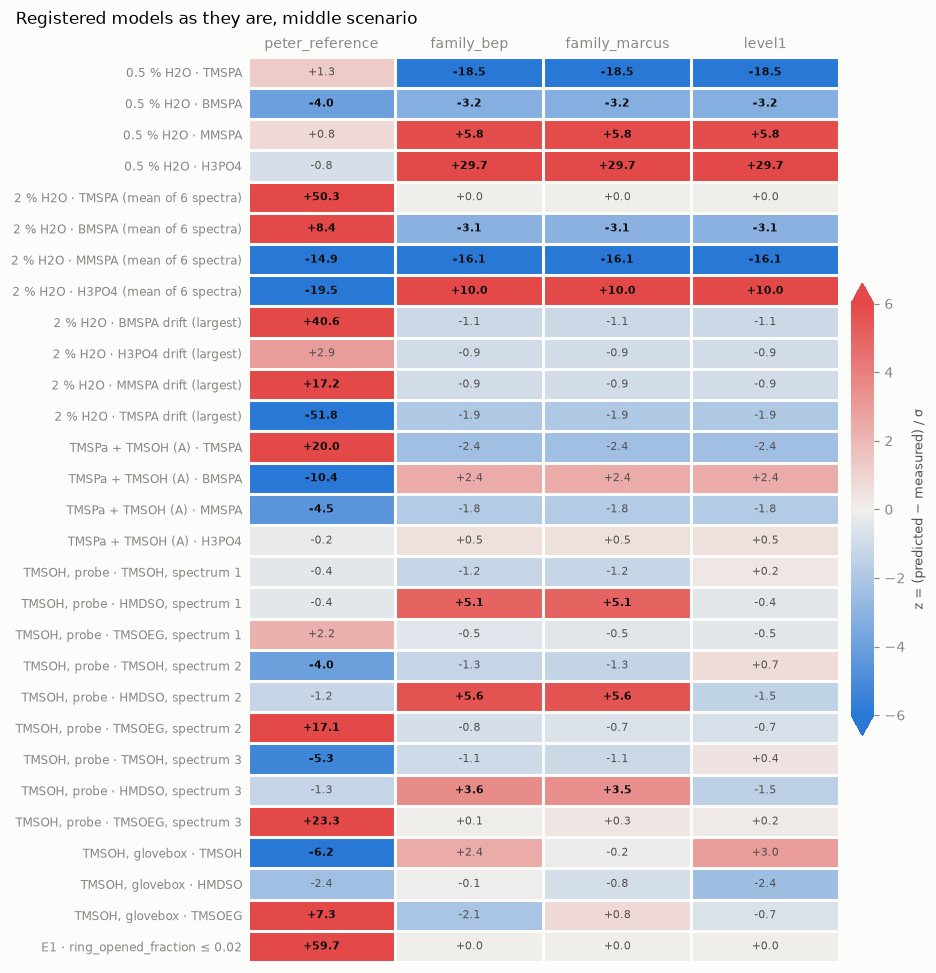

In [3]:
registered = read('registered.csv')
display(registered.pivot(index='model', columns='scenario', values='chi2').reindex(columns=list(SCENARIOS)).round(0)
        .rename_axis(columns='χ² (45 values)'))
display(registered[registered['scenario'] == 'middle'].set_index('model')[['chi2', 'max_abs_z', 'worst']].round(1))
fit_plots.plot_residual_map(read('registered_residuals.csv'), scenario='middle', columns='model',
                            title='Registered models as they are, middle scenario');

**Reading.**
- **None of the registered models describes the lab data.** That was expected: none was fitted to them.
- **`peter_reference`** (χ² 11 000–12 600): with 1.15 eV for every reaction, 62 % of the TMSOH opens an EC ring in a week at room temperature, where the paper sees none (E1, 60 SE), and the TMSOH heated in the probe would end at 64–81 % TMSOEG, where at most 3 % is measured (17–23 SE). At the same time hydrolysis is too slow: after one day the 2 % water sample would still hold 84 % of its TMSPA, where none is measured (50 SE).
- **`family_bep`, `family_marcus`, `level1`** (χ² 1 260–1 310): their 0.80 eV placeholders for hydrolysis and transfer finish the cascade in under a second, so the 0.5 % water sample, which still holds 93 % TMSPA, is predicted as 90 % H₃PO₄ (30 SE). The scenario makes no difference because everything has ended before the shortest age.
- **`level1` already describes the TMSOH samples:** no residual above 3 SE in the two ¹³C samples and E1 (the largest is 2.98, TMSOH in the glovebox sample). Its condensation and solvent-attack barriers came from the paper.

## 3. What data like ours can determine

Before the lab shares are touched: shares are generated from a known parameter set with the lab design (same samples, times, errors), noise is added, and the pipeline has to find the parameters again. Case A is M1-split, case B is M3-split with ΔG_rxn of R2 and R3 moved by +0.12 and +0.17 eV. The intervals are 95 % profile intervals.

,chi2_fit,chi2_truth,truths_inside,intervals
case,,,,
"A, seed 1",21.81,24.93,5,5
"A, seed 2",24.32,29.10,5,5
"A, seed 3",35.76,42.76,5,5
"B, seed 1",23.16,27.50,7,7
"B, seed 2",27.84,31.67,6,7


status,not determined,upper bound only,interval,lower bound only
parameter,,,,
g hydrolysis_R1,1,4,0,0
g hydrolysis_R23,0,3,2,0
g transfer,0,2,3,0
g condensation,3,0,0,2
g solvent_attack,0,0,5,0
dG R2,0,0,2,0
dG R3,0,0,2,0


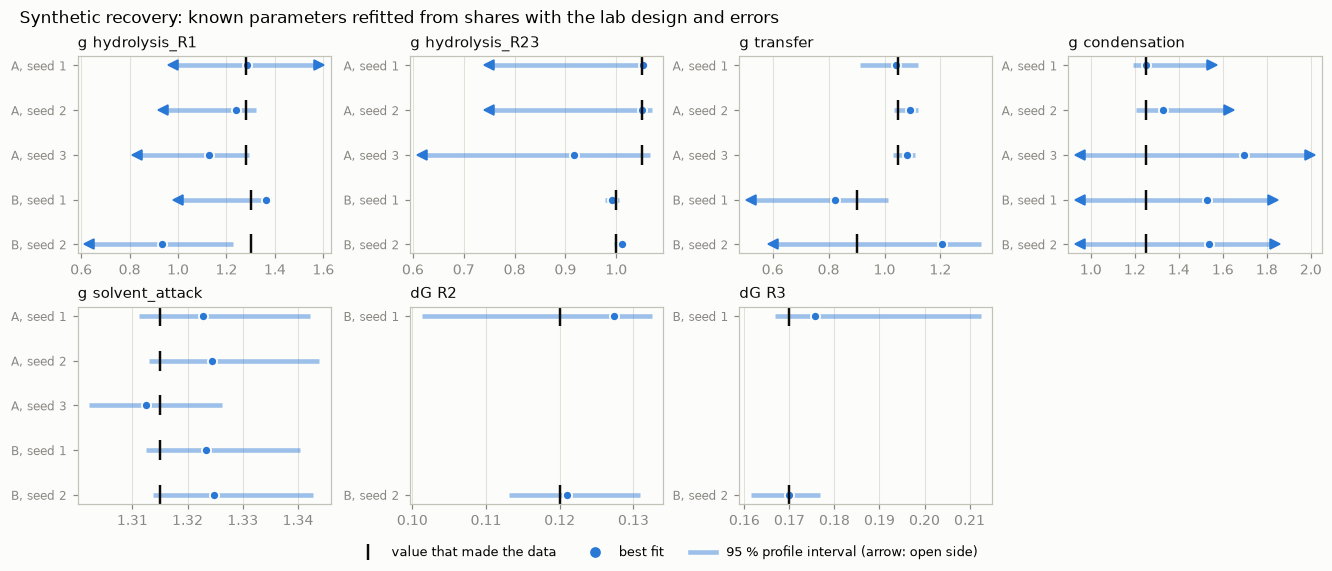

In [4]:
recovery = read('recovery_summary.csv')
cases = recovery.groupby('case').agg(chi2_fit=('chi2 fit', 'first'), chi2_truth=('chi2 truth', 'first'),
                                     truths_inside=('truth inside', 'sum'), intervals=('truth inside', 'size'))
display(cases.round(2))
fit_plots.plot_recovery(recovery);
recovery.groupby('parameter', sort=False)['status'].value_counts().unstack(fill_value=0)

**Reading.**
- **The search finds the optimum.** In all five synthetic data sets the fit reaches a χ² below that of the true parameters.
- **The intervals are honest.** 28 of the 29 true values lie inside their 95 % interval. The one outside is the R1 barrier in one M3-split case, where the fit settled in another basin (0.93 eV against the true 1.30 eV) and the interval ends at 1.23 eV.
- **What this design determines when the model is right:** the solvent-attack barrier (an interval of about ±0.015 eV every time), the barrier of R2 and R3 and the freed energies of R2 and R3 in the M3-split case (±0.01–0.02 eV).
- **What it does not, even when the model is right:** the R1 barrier gets an upper bound at most, condensation a lower bound or nothing, transfer an upper bound in the M3-split case.
- **Consequence for §5:** a "not determined" for R1 or for condensation in the lab fit is a property of the samples that exist, not a failure of the fit.

## 4. Every structure in every scenario

The best fit of each structure, simplest first. A cell reads χ² (largest |z|) and ✓ when the structure fits by the rule.

In [5]:
summary = read('fits_summary.csv')
summary['structure'] = pd.Categorical(summary['structure'], STRUCTURES)
summary = summary.sort_values('structure')
display(tables.format_structure_table(summary.assign(structure=summary['structure'].astype(str))))

parameters = read('fits_parameters.csv')
display(parameters.set_index(['structure', 'scenario']).reindex([(s, sc) for s in STRUCTURES for sc in SCENARIOS]).round(3).fillna('—'))

"χ² (largest |z|), ✓ = no |z| above 3",free parameters,short,middle,long,free
M0-BEP,1 (+1 age if free),3634 (60.1) ✗,3634 (60.1) ✗,3630 (60.0) ✗,3630 (60.0) ✗
M0-Marcus,1 (+1 age if free),3690 (59.8) ✗,3687 (59.7) ✗,3670 (59.4) ✗,3670 (59.4) ✗
M1,4 (+1 age if free),1067 (20.1) ✗,343 (16.1) ✗,320 (16.0) ✗,301 (16.0) ✗
M1-split,5 (+1 age if free),1021 (20.1) ✗,301 (16.0) ✗,291 (15.4) ✗,282 (15.0) ✗
M3,8 (+1 age if free),536 (11.6) ✗,294 (16.1) ✗,60 (4.1) ✗,27 (3.1) ✗
M3-split,9 (+1 age if free),535 (11.6) ✗,20 (1.9) ✓,20 (1.9) ✓,19 (1.9) ✓


g all reactions log10 age 2 % H2O g hydrolysis g transfer  \
structure scenario                                                             
M0-BEP    short              1.279                 —            —          —   
          middle             1.278                 —            —          —   
          long               1.276                 —            —          —   
          free               1.276             2.225            —          —   
M0-Marcus short              1.469                 —            —          —   
          middle             1.468                 —            —          —   
          long                1.46                 —            —          —   
          free                1.46             2.225            —          —   
M1        short                  —                 —         0.94      1.021   
          middle                 —                 —         1.41       0.81   
          long                   —                 —        1.397      0.701   
          free                   —             2.225        1.315      0.904   
M1-split  short                  —                 —            —        1.5   
          middle                 —                 —            —      0.988   
          long                   —                 —            —      1.035   
          free                   —             2.225            —      1.036   
M3        short                  —                 —        0.872      0.648   
          middle                 —                 —        1.421      0.661   
          long                   —                 —          1.7      0.786   
          free                   —             2.225        1.684      0.601   
M3-split  short                  —                 —            —       0.65   
          middle                 —                 —            —      0.646   
          long                   —                 —            —      0.657   
          free                   —             2.225            —      0.996   

                   g condensation g solvent_attack g hydrolysis_R1  \
structure scenario                                                   
M0-BEP    short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M0-Marcus short                 —                —               —   
          middle                —                —               —   
          long                  —                —               —   
          free                  —                —               —   
M1        short             1.125            1.306               —   
          middle            1.032            1.305               —   
          long              1.091            1.305               —   
          free              1.104            1.306               —   
M1-split  short             1.128            1.306            1.14   
          middle             1.13            1.306           1.458   
          long              1.214            1.309           1.402   
          free              1.262            1.308           1.314   
M3        short             1.349             1.31               —   
          middle            1.053            1.307               —   
          long              1.038            1.305               —   
          free              1.009            1.307               —   
M3-split  short              1.35             1.31           0.894   
          middle            1.268             1.31           1.493   
          long              1.232             1.31           1.449   
          free              1.329             1.31           1.109   

                   g hydrolysis_R23  dG R1  dG R2  dG R3  dG R4  
structure scenario                                 

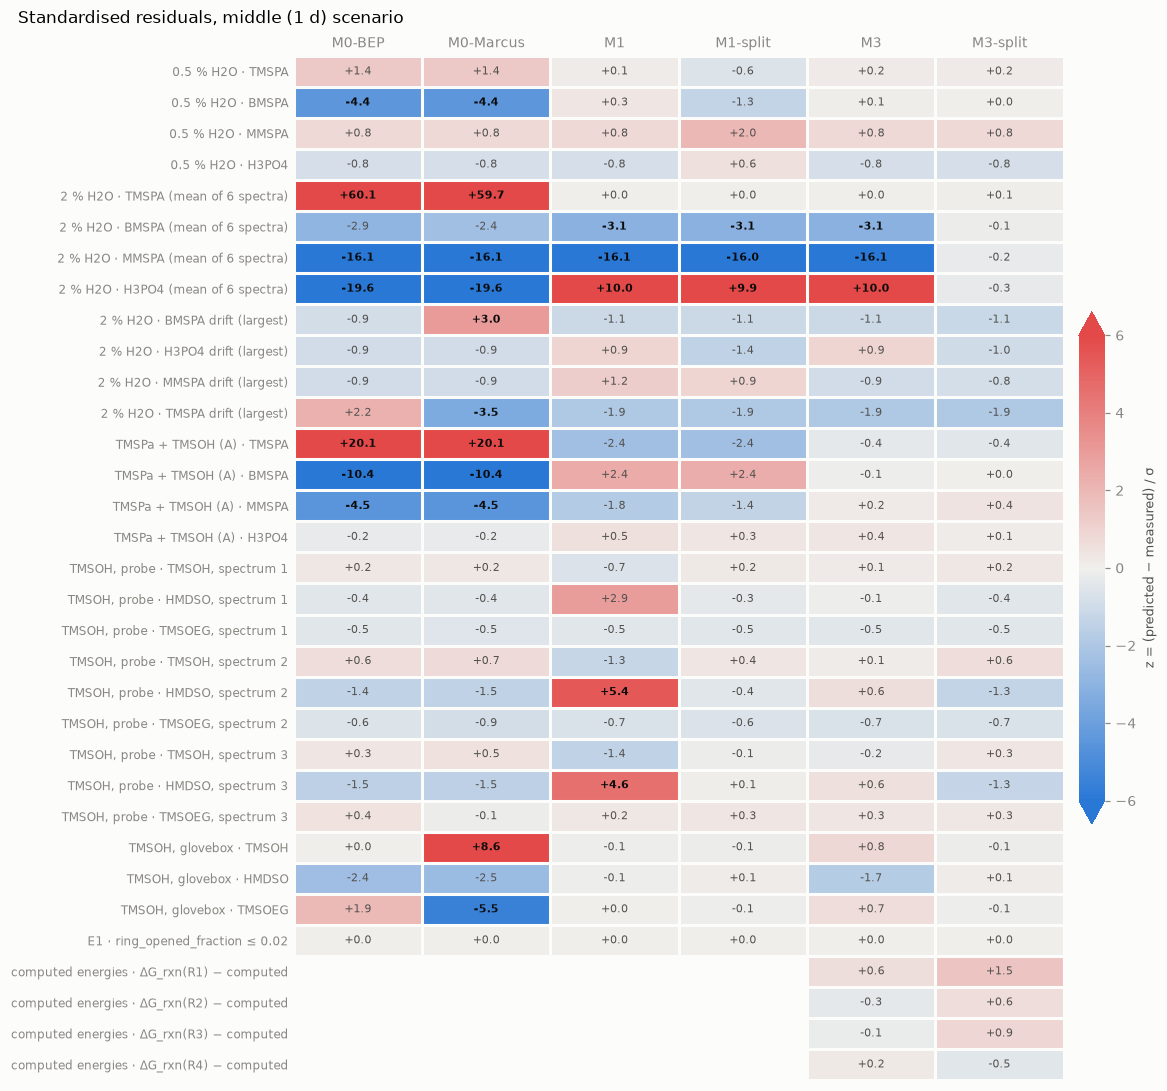

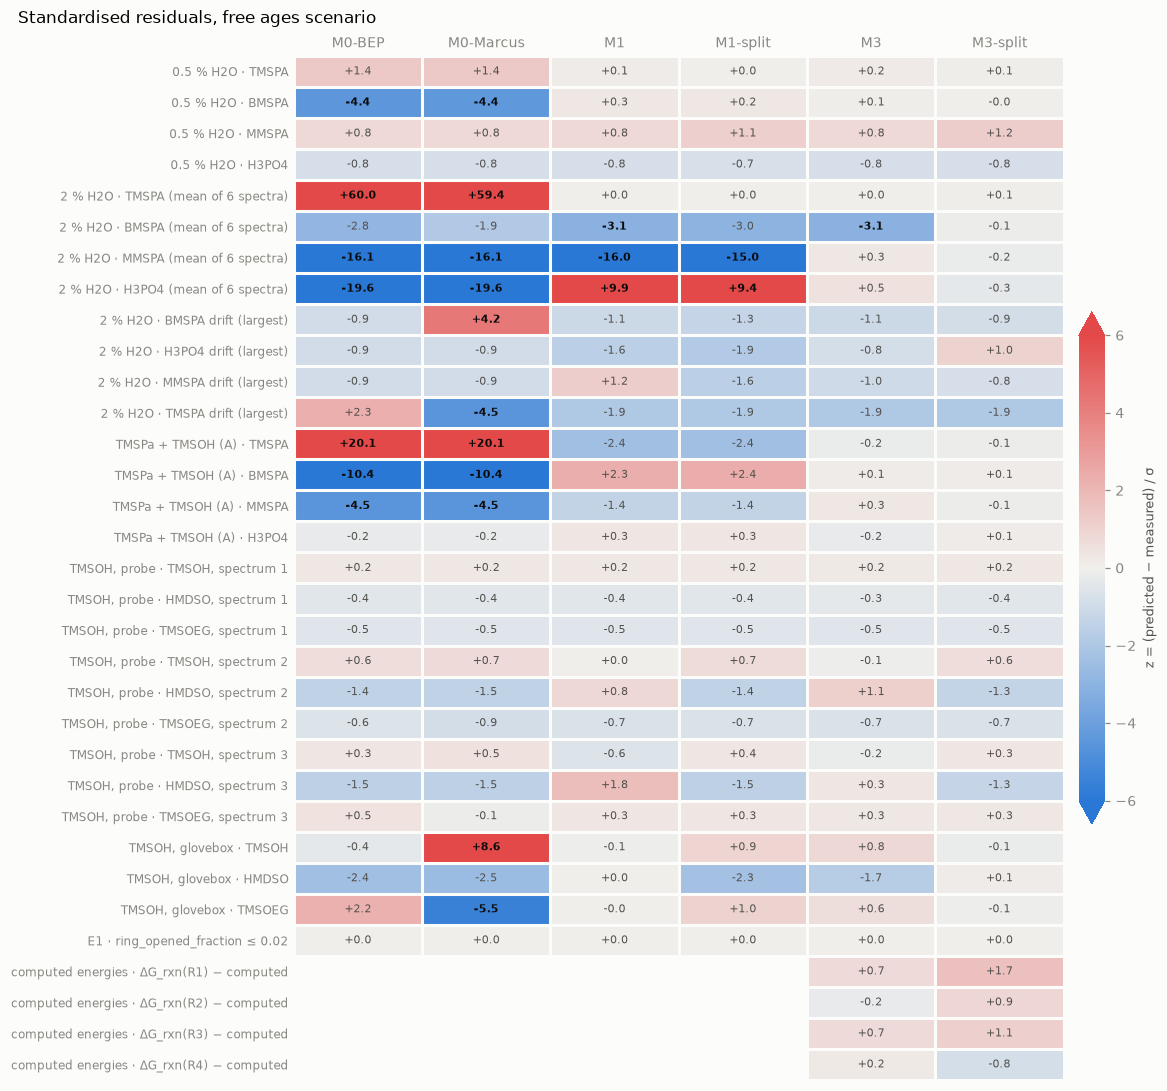

In [6]:
residuals = read('fits_residuals.csv')
for scenario in ('middle', 'free'):
    fit_plots.plot_residual_map(residuals, scenario=scenario, order=STRUCTURES)

**Reading.**
- **Only the largest structure fits, and it fits three scenarios.** M3-split reaches χ² 20.4 (middle), 19.8 (long) and 18.6 (free ages); its largest residual is 1.93 SE in each, a scatter among the six spectra of the 2 % sample that no model can remove. With every age at 1 h it fails (11.6 SE).
- **Each smaller structure fails for a reason that can be read off the map.**
  - *M1 and M1-split (computed reaction energies):* hydrolysis runs to the end, so the 2 % sample is predicted as 100 % H₃PO₄ where 66 % H₃PO₄ and 32 % MMSPA are measured (16 SE). That composition did not move in 145 h, heating to 80 °C included, so it is a resting state, and the computed energies do not allow one there.
  - *M3 (energies freed, one hydrolysis barrier):* the resting state is reached, but one barrier cannot serve R1 and R2–R3 at once. It fails the middle scenario (16 SE), the long one through HMDSO in the probe sample (4.1 SE) and free ages by a hair (3.06 SE, BMSPA of the 2 % sample).
- **The test is weak.** χ² is about 20 on 49 residuals, and leave-one-out (§5.3) shows that about 18 of it is the scatter of the 2 % spectra. The other samples are fitted almost exactly: nine parameters meet about 17 independent compositions (each spectrum gives one share less than it has windows).
- **By the rule fixed before fitting, the first consistent set is M3-split at a common age.** The rule does not say which common age when two fit; the code takes the lower χ², which is the long scenario by 0.5 (19.8 against 20.4). The data cannot tell the two apart.
- **That choice does not survive §4.3.** Both common-age fits rest on an induction time that a trace of TMSOH removes. No model is registered.

### 4.1 Peter's single barrier, presented fairly

`peter_reference` uses E₀ = 1.15 eV, chosen so that TMSPA consumption spreads over the 20–80 °C holds of the protocol: a design value, not a fit. The table gives the best single barrier in each form and scenario, next to the value 1.15 eV itself.

In [7]:
m0 = summary[summary['structure'].isin(['M0-BEP', 'M0-Marcus'])].merge(parameters, on=['structure', 'scenario'])
m0 = m0[['structure', 'scenario', 'g all reactions', 'chi2', 'max |z|', 'worst']].rename(columns={'g all reactions': 'best barrier (eV)'})
display(m0.set_index(['structure', 'scenario']).round(3))
registered[registered['model'] == 'peter_reference'].set_index('scenario')[['chi2', 'max_abs_z', 'worst']].round(1).rename_axis('peter_reference at 1.15 eV')

best barrier (eV)      chi2  max |z|  \
structure scenario                                         
M0-BEP    short                 1.279  3634.158   60.094   
          middle                1.278  3633.607   60.087   
          long                  1.276  3630.037   60.042   
          free                  1.276  3630.175   60.042   
M0-Marcus short                 1.469  3689.656   59.767   
          middle                1.468  3687.408   59.721   
          long                  1.460  3670.487   59.362   
          free                  1.460  3670.488   59.362   

                                                 worst  
structure scenario                                      
M0-BEP    short     2 % H2O: TMSPA (mean of 6 spectra)  
          middle    2 % H2O: TMSPA (mean of 6 spectra)  
          long      2 % H2O: TMSPA (mean of 6 spectra)  
          free      2 % H2O: TMSPA (mean of 6 spectra)  
M0-Marcus short     2 % H2O: TMSPA (mean of 6 spectra)  
          middle    2 % H2O: TMSPA (mean of 6 spectra)  
          long      2 % H2O: TMSPA (mean of 6 spectra)  
          free      2 % H2O: TMSPA (mean of 6 spectra)

,chi2,max_abs_z,worst
peter_reference at 1.15 eV,,,
short,12640.8,59.7,E1: ring_opened_fraction ≤ 0.02
middle,12419.2,59.7,E1: ring_opened_fraction ≤ 0.02
long,11343.6,59.7,E1: ring_opened_fraction ≤ 0.02
free,10978.0,59.7,E1: ring_opened_fraction ≤ 0.02


**Reading.**
- **The best single barrier is 1.28 eV in Peter's capped-BEP form and 1.46–1.47 eV in the Marcus form** (χ² ≈ 3 630–3 690). At that value nothing reacts at room temperature: every phosphate sample is predicted as 100 % TMSPA (60 SE in the 2 % water sample). The fit gives up hydrolysis: a barrier low enough to consume TMSPA in the 2 % water sample would also consume it in the 0.5 % sample and let TMSOH open EC.
- **At 1.15 eV the misfit is three times larger** (χ² ≈ 11 000–12 600): hydrolysis is still too slow for the 2 % water sample and solvent attack is already too fast (§2).
- **So the data reject the structure, not the value.** Solvent attack needs about 1.29 eV at 80 °C to leave TMSOH alone at room temperature, and TMSPA has to be consumed within days at room temperature, which needs a step of about 1.1 eV or less. No single barrier does both.
- **This says nothing against the purpose of `peter_reference`.** 1.15 eV was chosen so that the consumption of TMSPA spreads over the holds of the protocol, as a design value for planning the measurement. It was never a fit, and the comparison here is against data it was not meant to describe.

### 4.2 Barriers and energies of the largest structure

ΔG‡ of each reaction at the temperature where its family is observed (22.5 °C for hydrolysis and transfer, 80 °C for condensation and solvent attack) and its ΔG_rxn, for the best fit of M3-split in each scenario. These are the numbers the data act on; the family barrier g follows from them through the Marcus relation and the reaction energy.

In [8]:
barriers = read('fits_barriers.csv')
main = barriers[barriers['structure'] == MAIN]
display(pd.concat({'ΔG‡ (eV)': main.pivot(index='reaction', columns='scenario', values='dG_barrier_eV'),
                   'ΔG_rxn (eV)': main.pivot(index='reaction', columns='scenario', values='dG_rxn_eV')}, axis=1)
        .reindex(columns=list(SCENARIOS), level=1).round(3))

ΔG‡ (eV)                      ΔG_rxn (eV)                     
scenario    short middle   long   free       short middle   long   free
reaction                                                               
R1          0.970  1.449  1.391  1.088       0.149 -0.088 -0.117 -0.041
R2          0.917  0.948  1.007  1.037       0.107 -0.005 -0.035  0.053
R3          0.915  0.966  1.027  1.057       0.103  0.031  0.006  0.091
R4          1.240  1.241  1.239  1.241      -0.224 -0.055  0.014 -0.181
R5          0.613  0.577  0.606  0.888      -0.075 -0.143 -0.103 -0.222
R6          0.592  0.617  0.646  0.933      -0.117 -0.060 -0.022 -0.128
R7          0.590  0.634  0.666  0.951      -0.121 -0.024  0.019 -0.090
R8          1.287  1.287  1.287  1.287      -0.047 -0.047 -0.047 -0.047
R9          1.087  1.087  1.087  1.087      -0.467 -0.467 -0.467 -0.467

**Reading.**
- **The same in every scenario that fits:** solvent attack, ΔG‡(R8) = 1.287 eV at 80 °C; condensation, ΔG‡(R4) = 1.24 eV at 80 °C; the second and third hydrolysis, ΔG‡(R2) = 0.95–1.04 eV and ΔG‡(R3) = 0.97–1.06 eV at 22 °C.
- **Different in every scenario:** hydrolysis of TMSPA itself, ΔG‡(R1) = 1.45 (middle), 1.39 (long), 1.09 eV (free); transfer, ΔG‡(R5) = 0.58, 0.61, 0.89 eV. These two are what the unknown ages decide.
- **Reaction energies move by 0.09–0.43 eV from the computed values,** within 1.7 standard errors of them. R1 goes from −0.47 to between −0.12 and −0.04 eV, R2 from −0.16 to between −0.04 and +0.05 eV, R3 from −0.18 to between +0.01 and +0.09 eV, R4 from +0.10 to between −0.18 and +0.01 eV. What the data see are R2 and R3 close to zero (the resting composition of the 2 % sample) and the transfer equilibria of tube A.
- **R6, R7 and R9 are not measured separately.** Their rows follow from the family barrier and the reaction energy.

### 4.3 How a fit reaches the two water samples, and what a trace of TMSOH does to it

Every fit starts the two water samples from their recipe: TMSPA, water, solvent, and no TMSOH. The figure follows TMSPA in both samples from mixing, for the best fit of M3-split in each scenario that it fits, and repeats the run with 1 µM of TMSOH present at mixing (7 ppm of the TMSPA). The first table gives χ² of each fit, unchanged, against the same data when that trace is added; the second gives the fit made again with the trace in place.

hours from mixing until half of the TMSPA is gone  middle   long   free
sample    TMSOH at mixing                                              
0.5 % H2O none                                       46.1  222.5  124.5
          1 µM                                       18.5  159.7  124.5
2 % H2O   none                                       12.8   59.1   29.2
          1 µM                                        5.1   40.7   29.2

χ² of the fit as it is,short,middle,long,free
TMSOH at mixing,,,,
none,534.7,20.4,19.8,18.6
1 nM,534.7,372.9,19.8,18.6
100 nM,534.7,1112.3,269.8,18.6
1 µM,534.7,1110.9,1542.2,18.6
10 µM,534.6,1110.8,1306.0,18.6
100 µM,534.6,1110.8,1257.8,18.6
1 mM,534.5,1110.7,1237.3,18.9


chi2  max |z|  \
TMSOH at mixing scenario                    
1 µM            middle    28.178    2.500   
                long      21.084    1.934   
                free      18.588    1.934   
1 mM            middle    37.337    3.862   
                long      23.128    2.004   
                free      18.698    1.934   

                                                             worst   fits  \
TMSOH at mixing scenario                                                    
1 µM            middle                            0.5 % H2O: BMSPA   True   
                long              2 % H2O: TMSPA drift, spectrum 4   True   
                free              2 % H2O: TMSPA drift, spectrum 4   True   
1 mM            middle                            0.5 % H2O: MMSPA  False   
                long      computed energies: ΔG_rxn(R1) − computed   True   
                free              2 % H2O: TMSPA drift, spectrum 4   True   

                          dG‡ R1  dG‡ R2  dG‡ R5  dG‡ R4  dG‡ R8  
TMSOH at mixing scenario                                          
1 µM            middle     1.235   0.951   0.892   1.241   1.287  
                long       1.359   1.007   0.583   1.240   1.287  
                free       1.088   1.037   0.888   1.241   1.287  
1 mM            middle     1.305   0.982   0.778   1.237   1.287  
                long       1.690   1.040   0.673   1.239   1.287  
                free       1.091   1.038   0.874   1.241   1.287

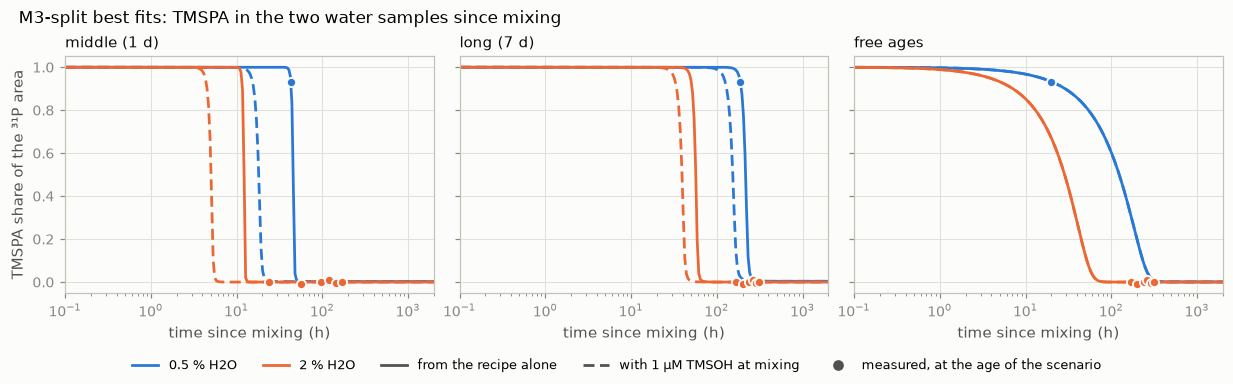

In [9]:
trajectories = read('sample_trajectories.csv')
fit_plots.plot_sample_trajectories(trajectories, structure=MAIN);
curves = trajectories[(trajectories['kind'] == 'model') & (trajectories['TMSPA'] < 0.5)]
curves = curves.assign(**{'TMSOH at mixing': curves['TMSOH at mixing (M)'].map(show_M)})
display(curves.groupby(['scenario', 'sample', 'TMSOH at mixing'], sort=False)['t_h'].min().unstack('scenario').reindex(columns=list(FITTING)).round(1)
        .rename_axis(columns='hours from mixing until half of the TMSPA is gone'))

traces = read('trace_sensitivity.csv')
traces['TMSOH at mixing'] = traces['TMSOH at mixing (M)'].map(show_M)
scan = traces[traces['parameters'] == 'as fitted without it']
display(scan.pivot_table(index='TMSOH at mixing', columns='scenario', values='chi2', sort=False).reindex(columns=list(SCENARIOS)).round(1)
        .rename_axis(columns='χ² of the fit as it is'))
again = traces[traces['parameters'] == 'fitted again']
again.set_index(['TMSOH at mixing', 'scenario'])[['chi2', 'max |z|', 'worst', 'fits'] + [f'dG‡ {r}' for r in ('R1', 'R2', 'R5', 'R4', 'R8')]].round(3)

**Reading.**
- **How a common age serves both samples.** In the middle and long fits TMSPA does not hydrolyse on its own (k₁ ≈ 10⁻¹² to 10⁻¹¹ M⁻¹ s⁻¹). It is consumed by TMSOH through transfer, and each TMSPA consumed returns two TMSOH when BMSPA and MMSPA hydrolyse, so TMSOH multiplies. Its amount grows by a factor e every 1/(k₂[H₂O]): 37 min at 2 % water and four times longer at 0.5 % in the middle fit. Nothing is visible for about twenty of these times, then TMSPA is gone within an hour: after 12 h at 2 % water and 46 h at 0.5 %. At 24 h the 2 % sample is past its cliff; at 43 h the 0.5 % sample is 3 h before its own.
- **The cliff is timed by what seeds it.** With no TMSOH in the recipe, the seed is what R1 makes in the first 37 min: about 0.4 nM. Adding 1 nM of TMSOH at mixing takes the middle fit from χ² 20 to 373; 100 nM takes it above 1 000 and the long fit to 270, 1 µM both above 1 000.
- **The samples were not that clean.** The first spectrum of TMSPa without added water shows 12 ± 5 % BMSPA, and the 0.5 % sample 6 %. Each hydrolysed phosphate has released a silyl group, so TMSOH or HMDSO at the millimolar level at mixing is the likely case.
- **Fitted again with a trace:** with 1 µM the middle and long scenarios still fit (χ² 28.2 and 21.1), with 1 mM the long one does (23.1) and the middle one does not (3.9 SE). ΔG‡(R1) then lies anywhere from 1.24 to 1.69 eV and ΔG‡(R5) from 0.58 to 0.89 eV. In a common-age scenario these two barriers are set by the assumed trace, not by the data.
- **The free-age fit is ordinary kinetics** and does not depend on a trace: χ² 18.6 from 0 to 0.1 mM, 18.7 fitted again with 1 mM, barriers unchanged within 0.015 eV.
- **What does not change with the trace or the scenario:** ΔG‡(R8) = 1.287 eV, ΔG‡(R4) = 1.24 eV, ΔG‡(R2) = 0.95–1.04 eV, ΔG‡(R3) = 0.97–1.06 eV.

## 5. Blind spots

### 5.1 Intervals: what is determined, bounded, or not determined

95 % profile intervals (Δχ² ≤ 3.84 with every other parameter re-minimised). A side on which the profile never rises that far inside its grid (±0.30 eV for a barrier, ±2 standard errors for an energy) is left open.

M1: 95 % interval,short,middle,long,free
g condensation,1.100–1.209,1.019–1.036,1.081–1.092,1.094–1.108
g hydrolysis,≤ 0.990,1.387–1.469,1.387–1.416,1.305–1.365
g solvent_attack,1.294–1.323,1.293–1.320,1.294–1.322,1.294–1.321
g transfer,1.016–1.025,≤ 0.952,≤ 0.963,≤ 1.009
log10 age 2 % H2O,—,—,—,≥ 2.10


M3-split+W: 95 % interval,short,middle,long,free
water fraction,—,≥ 0.20,—,≥ 0.20


M3-split: 95 % interval,short,middle,long,free
dG R1,≥ 0.557,≥ 0.342,0.295–0.658,0.313–0.652
dG R2,0.202–0.382,0.130–0.271,0.083–0.397,0.099–0.416
dG R3,0.208–0.385,0.179–0.451,0.174–0.483,0.181–0.471
dG R4,-0.573–-0.148,≤ -0.064,≤ -0.049,≤ -0.077
g condensation,1.268–1.515,1.210–1.349,1.201–1.518,1.215–1.532
g hydrolysis_R1,0.833–0.972,≥ 1.218,not determined,0.998–1.175
g hydrolysis_R23,0.820–0.899,0.900–0.978,0.890–1.029,0.891–1.048
g solvent_attack,1.298–1.327,1.298–1.326,1.297–1.327,1.298–1.325
g transfer,≤ 0.779,≤ 0.840,≤ 0.914,≤ 1.067
log10 age 2 % H2O,—,—,—,≥ 1.70


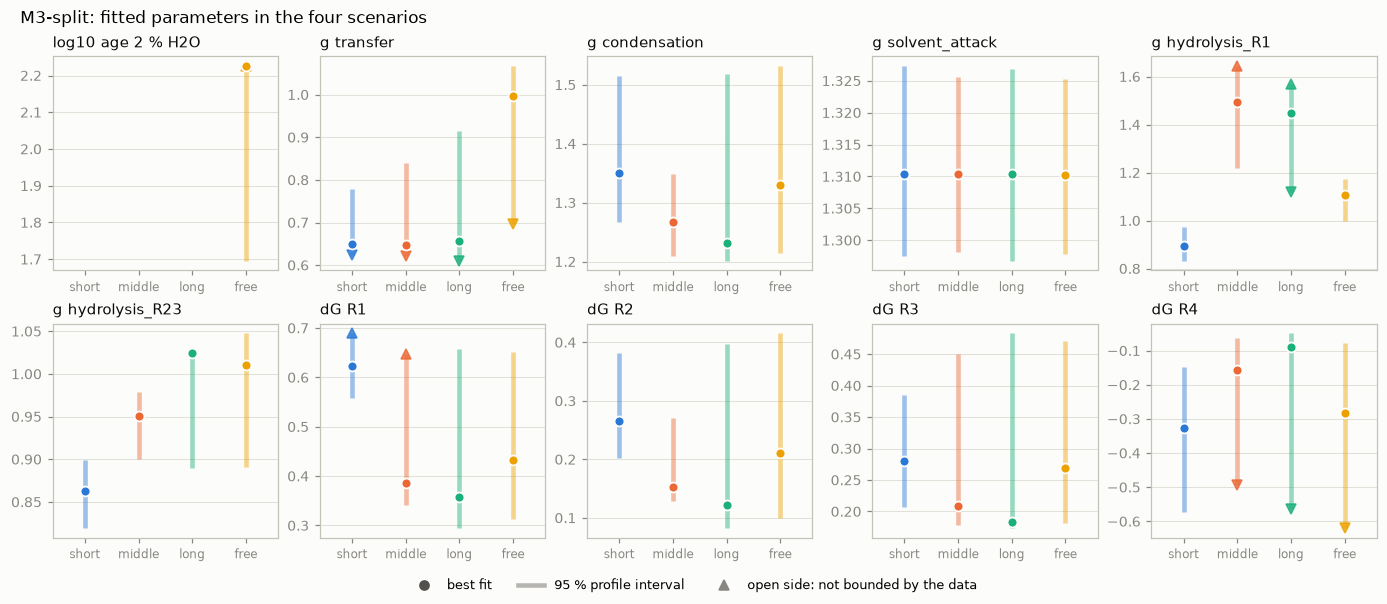

In [10]:
intervals = read('intervals.csv')
for structure in dict.fromkeys(intervals.loc[intervals['tag'].fillna('') == '', 'structure']):
    display(tables.format_interval_table(intervals, structure).rename_axis(f'{structure}: 95 % interval', axis=1))
fit_plots.plot_fit_across_scenarios(parameters, intervals, structure=MAIN);

ΔG‡ over the accepted sets (eV)                            \
scenario                           short       middle         long   
reaction                                                             
R1                           0.954–1.029  1.232–1.594  1.194–1.648   
R2                           0.905–0.926  0.931–0.979  0.968–1.046   
R3                           0.903–0.924  0.948–0.998  0.985–1.063   
R4                           1.226–1.539  1.225–1.275  1.234–1.256   
R5                           0.538–0.780  0.416–0.732  0.413–0.862   
R6                           0.521–0.760  0.450–0.772  0.450–0.902   
R7                           0.518–0.758  0.465–0.790  0.465–0.921   
R8                           1.285–1.293  1.279–1.295  1.286–1.288   
R9                           1.085–1.093  1.079–1.096  1.086–1.088   

                      ΔG_rxn over the accepted sets (eV)                    \
scenario         free                              short            middle   
reaction                                                                     
R1        1.075–1.139                   +0.068 to +0.268  -0.132 to +0.173   
R2        0.987–1.049                   +0.025 to +0.230  -0.037 to +0.256   
R3        1.005–1.068                   +0.022 to +0.223  +0.003 to +0.290   
R4        1.232–1.249                   -0.466 to -0.056  -0.579 to +0.029   
R5        0.591–0.993                   -0.198 to +0.012  -0.406 to -0.089   
R6        0.631–1.044                   -0.236 to -0.031  -0.324 to -0.008   
R7        0.648–1.067                   -0.242 to -0.034  -0.290 to +0.032   
R8        1.278–1.295                   -0.047 to -0.047  -0.047 to -0.047   
R9        1.079–1.095                   -0.467 to -0.467  -0.467 to -0.467   

                                              
scenario              long              free  
reaction                                      
R1        -0.128 to +0.185  -0.150 to +0.177  
R2        -0.044 to +0.271  -0.050 to +0.271  
R3        -0.000 to +0.306  +0.008 to +0.307  
R4        -0.612 to +0.041  -0.615 to +0.010  
R5        -0.427 to -0.086  -0.438 to -0.120  
R6        -0.341 to -0.002  -0.344 to -0.028  
R7        -0.306 to +0.041  -0.308 to +0.018  
R8        -0.047 to -0.047  -0.047 to -0.047  
R9        -0.467 to -0.467  -0.467 to -0.467

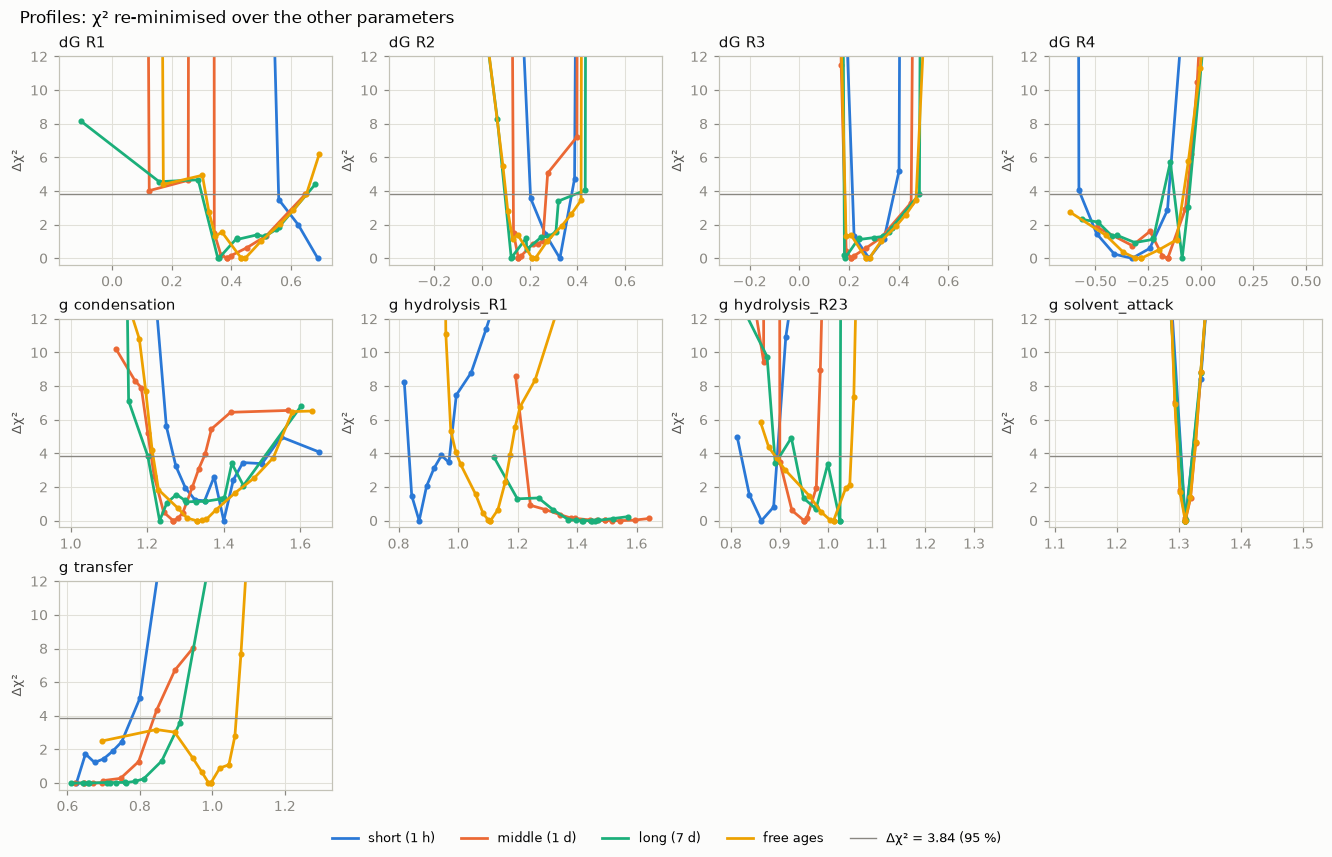

In [11]:
profiles = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))['profile'] for scenario in SCENARIOS}
fit_plots.plot_profiles(profiles);
bands = read('barrier_bands.csv')
band = bands[bands['structure'] == MAIN]
band = band.assign(interval=[f"{lo:.3f}–{hi:.3f}" for lo, hi in zip(band['dG‡ low'], band['dG‡ high'])],
                   energy=[f"{lo:+.3f} to {hi:+.3f}" for lo, hi in zip(band['dG_rxn low'], band['dG_rxn high'])])
pd.concat({'ΔG‡ over the accepted sets (eV)': band.pivot(index='reaction', columns='scenario', values='interval'),
           'ΔG_rxn over the accepted sets (eV)': band.pivot(index='reaction', columns='scenario', values='energy')}, axis=1).reindex(
    columns=list(SCENARIOS), level=1)

**Reading.**
- **Determined in every scenario that fits:** the solvent-attack barrier (1.297–1.327 eV, the same interval three times); the barrier of R2 and R3 (0.89–1.05 eV); the condensation barrier (1.20–1.53 eV, 1.21–1.35 in the middle scenario); the shifts of ΔG_rxn of R2 (+0.08 to +0.42 eV) and R3 (+0.17 to +0.48 eV). Both shifts exclude zero: the data reject the computed energies of R2 and R3.
- **Bounded on one side:** the transfer barrier from above (0.84, 0.91 and 1.07 eV in the middle, long and free scenarios); the shift of ΔG_rxn(R4) from above (−0.05 to −0.08 eV).
- **Hydrolysis of TMSPA (R1):** barrier at least 1.22 eV (middle), not determined (long), 1.00–1.18 eV (free ages). Its ΔG_rxn shift is at least +0.29 eV in all three.
- **Ages:** with free ages the 2 % sample is at least 50 h old at its first spectrum. The best fit puts it at the 7 d limit and the 0.5 % sample at the 1 h limit.
- **Every interval is conditional** on its scenario and on samples that start from the recipe alone. With 1 µM TMSOH at mixing the middle scenario needs a transfer barrier of 0.96 eV (§4.3), outside its interval here. What holds across scenarios and traces is the last line of §4.3.
- **Second table:** the same information per reaction, as the range of ΔG‡ and ΔG_rxn over the profile points inside the intervals. It counts computed points only, so a range can be narrower than its interval (R8 in the long scenario).

### 5.2 Combinations the data see

Singular vectors of the residual sensitivities at the best fit, for the middle scenario and for free ages: each row is one combination of the parameters, with the standard error the data give along it. Large values are directions the data do not determine. These are local statements at the best fit; the profiles of §5.1 are the ones that hold away from it.

In [12]:
def show_meV(value_eV):
    return 'over 1 000' if value_eV > 1.0 else f'{1000 * value_eV:.1f}'


for scenario in ('middle', 'free'):
    bundle = load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}__{scenario}.json'))
    directions = bundle['directions']
    display(directions.drop(columns='sigma_eV').round(2).set_index(directions['sigma_eV'].map(show_meV).rename(f'{scenario}: standard error along the combination (meV)')))
    display(pd.Series(bundle['sigma_local']).map(show_meV).rename(f'{scenario}: local standard error (meV)').to_frame().T)

,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
middle: standard error along the combination (meV),,,,,,,,,
0.1,-0.08,-0.97,-0.06,-0.00,-0.00,-0.04,-0.21,-0.05,0.03
2.3,-0.00,-0.04,-0.00,0.01,0.00,-0.00,0.01,0.91,0.41
6.7,-0.00,0.00,-0.00,-0.01,1.00,0.00,-0.01,0.00,-0.01
7.2,-0.01,0.17,-0.01,-0.04,-0.01,0.26,-0.90,0.13,-0.26
12.8,0.01,-0.04,0.01,-0.86,-0.02,-0.20,0.12,0.18,-0.41
17.6,-0.05,0.07,-0.04,0.29,0.00,-0.91,-0.19,0.09,-0.20
37.0,0.48,-0.14,0.36,0.35,-0.00,0.17,0.21,0.26,-0.60
228.6,-0.63,0.00,-0.48,0.22,-0.00,0.20,0.21,0.19,-0.45
over 1 000,-0.60,0.00,0.80,-0.00,0.00,-0.00,-0.00,-0.00,0.00


,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
middle: local standard error (meV),over 1 000,762.7,over 1 000,54.7,6.7,50.1,50.1,46.3,107.4


,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
free: standard error along the combination (meV),,,,,,,,,
2.1,-0.01,-0.13,0.06,-0.00,0.00,-0.00,-0.03,-0.89,-0.44
6.1,-0.10,-0.84,0.50,0.01,0.03,-0.08,-0.01,0.11,0.10
6.7,0.01,0.02,-0.01,-0.02,1.00,0.01,-0.00,0.00,-0.01
7.3,-0.67,0.09,-0.08,0.02,0.01,-0.59,0.42,-0.07,0.09
8.3,-0.45,-0.02,-0.13,-0.06,-0.01,-0.12,-0.82,0.15,-0.26
13.1,-0.07,-0.03,-0.12,0.89,0.02,0.07,-0.16,-0.18,0.35
18.5,0.08,-0.49,-0.82,-0.19,-0.00,-0.00,0.04,-0.07,0.16
23.7,0.54,-0.04,-0.05,0.24,0.00,-0.72,-0.07,0.16,-0.31
394.2,0.19,0.14,0.16,-0.33,-0.00,-0.33,-0.34,-0.34,0.69


,g hydrolysis_R1,g hydrolysis_R23,g transfer,g condensation,g solvent_attack,dG R1,dG R2,dG R3,dG R4
free: local standard error (meV),78.0,57.2,64.3,131.7,6.7,129.8,133.1,133.7,270.8


**Reading.**
- **Middle scenario:** one combination is held to 0.13 meV. It is the barrier of R2–R3 together with ΔG_rxn(R2): the timing of the cliff against the single spectrum of the 0.5 % sample. This is not a precision of measurement; it says how sharply this fit depends on that one spectrum. One combination of the R1 and transfer barriers is not held at all (far over 1 eV) and a second only to 0.23 eV: once R1 is frozen and transfer is fast, their values no longer matter.
- **Free ages:** eight combinations are held to 2–24 meV. The ninth (394 meV) moves the four reaction energies together and is held by the computed values alone.
- **Local errors against profiles:** with free ages the two are of the same size (R1 barrier: local standard error 0.08 eV, profile interval 1.00–1.18 eV). In the middle scenario they are not, which is why §5.1 uses profiles.

### 5.3 Which sample drives which value

The fit of M3-split repeated without each sample in turn. The map shows how far ΔG‡ of each reaction moves; the table says whether the structure then fits.

largest |z| without the sample,middle,long,free
left out,,,
0.5 % H2O,1.93,1.93,1.93
2 % H2O,0.78,0.79,0.78
E1,1.93,1.93,1.93
"TMSOH, glovebox",1.93,1.96,1.93
"TMSOH, probe",1.93,1.93,1.93
TMSPa + TMSOH (A),1.93,1.93,1.93


χ² without the sample,middle,long,free
left out,,,
0.5 % H2O,19.4,17.3,16.8
2 % H2O,2.3,2.1,2.4
E1,20.4,20.8,18.6
"TMSOH, glovebox",18.1,18.7,16.1
"TMSOH, probe",17.1,17.9,15.2
TMSPa + TMSOH (A),17.2,17.4,14.8


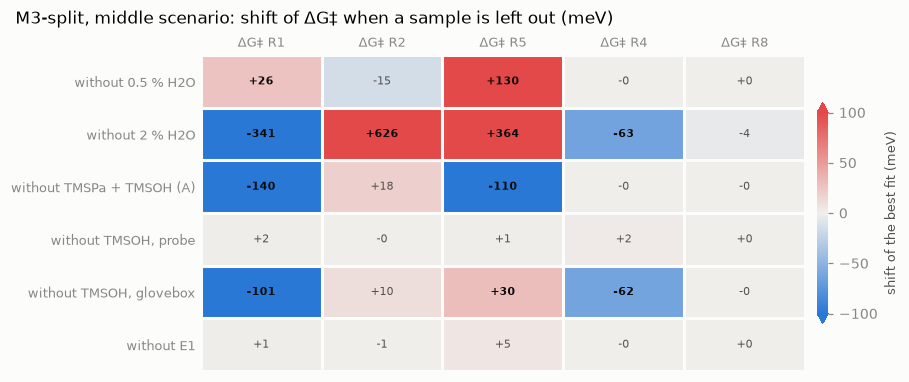

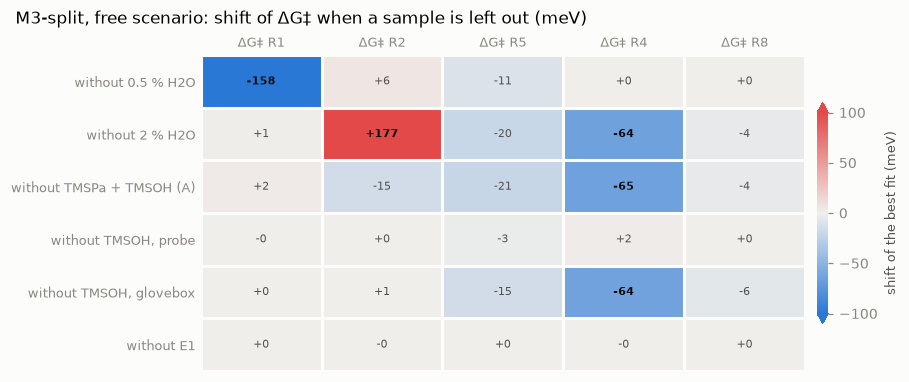

In [13]:
loo = read('leave_one_out.csv')
barrier_columns = [f'dG‡ {r}' for r in ('R1', 'R2', 'R5', 'R4', 'R8')]
fit_barriers = barriers[barriers['structure'] == MAIN].pivot(index='scenario', columns='reaction', values='dG_barrier_eV')
for scenario in ('middle', 'free'):
    table = loo[(loo['structure'] == MAIN) & (loo['scenario'] == scenario)]
    fit_plots.plot_influence(table, {c: fit_barriers.loc[scenario, c.split(' ')[1]] for c in barrier_columns}, columns=barrier_columns,
                             title=f'{MAIN}, {scenario} scenario: shift of ΔG‡ when a sample is left out (meV)')
display(loo[loo['structure'] == MAIN].pivot(index='left out', columns='scenario', values='max |z|').reindex(columns=list(FITTING)).round(2)
        .rename_axis(columns='largest |z| without the sample'))
loo[loo['structure'] == MAIN].pivot(index='left out', columns='scenario', values='chi2').reindex(columns=list(FITTING)).round(1).rename_axis(columns='χ² without the sample')

**Reading.**
- **The 2 % water sample carries χ² and the R2–R3 barrier.** Without it χ² falls from about 20 to 2.1–2.4 and ΔG‡(R2) runs up to 1.2–1.6 eV, the end of its box in two scenarios. It is the only sample in which hydrolysis is seen past BMSPA.
- **The 0.5 % water sample sets R1.** Without it ΔG‡(R1) falls by 0.16 eV with free ages (1.09 to 0.93 eV). In the long scenario it falls from 1.39 to 0.98 eV and ΔG‡(R5) rises from 0.61 to 0.88 eV: the induction time of §4.3 is there because of this one spectrum.
- **Tube A sets transfer** in the common-age scenarios (ΔG‡(R5) falls by 0.11 eV in the middle scenario without it) and, with free ages, part of condensation (ΔG‡(R4) falls by 0.07 eV).
- **The glovebox sample sets condensation:** ΔG‡(R4) falls by 0.06 eV without it.
- **The probe sample and E1 move nothing** (at most 0.003 eV). What they say about solvent attack is also said by the glovebox sample, and without that sample they hold ΔG‡(R8) within 0.007 eV.
- **Every fit without one sample still fits** (largest residual 1.96 SE), so no sample contradicts the others. The other side of this: solvent attack is the only barrier that two samples check. Each of the others rests on one spectrum.

### 5.4 Structures the data cannot tell apart

Each row is one structure fitted either to the lab shares or to noise-free shares made by another structure with the lab design. If a structure reproduces shares made by another within 3 standard errors, this data set cannot separate the two.

fitted  \
scenario question                                                  
middle   equilibrium or exhausted water               M3-split+W   
         equilibrium or exhausted water               M1-split+W   
         equilibrium or exhausted water               M1-split+W   
         equilibrium or exhausted water                 M3-split   
         Marcus or Agmon–Levine          M3-split (agmon_levine)   
         one hydrolysis barrier or two                        M3   
         one hydrolysis barrier or two                        M3   
free     equilibrium or exhausted water               M3-split+W   
         equilibrium or exhausted water               M1-split+W   
         equilibrium or exhausted water               M1-split+W   
         equilibrium or exhausted water                 M3-split   
         Marcus or Agmon–Levine          M3-split (agmon_levine)   
         one hydrolysis barrier or two                        M3   
         one hydrolysis barrier or two                        M3   

                                                       data    chi2  max |z|  \
scenario question                                                              
middle   equilibrium or exhausted water                 lab   20.38     1.93   
         equilibrium or exhausted water                 lab   82.12     7.11   
         equilibrium or exhausted water    made by M3-split   67.81     6.86   
         equilibrium or exhausted water  made by M1-split+W   11.25     1.56   
         Marcus or Agmon–Levine                         lab   20.38     1.93   
         one hydrolysis barrier or two     made by M3-split  282.10    15.90   
         one hydrolysis barrier or two                  lab  294.03    16.10   
free     equilibrium or exhausted water                 lab   18.21     1.93   
         equilibrium or exhausted water                 lab   78.69     7.07   
         equilibrium or exhausted water    made by M3-split   65.44     6.89   
         equilibrium or exhausted water  made by M1-split+W    5.03     1.57   
         Marcus or Agmon–Levine                         lab   18.55     1.93   
         one hydrolysis barrier or two     made by M3-split   21.29     2.95   
         one hydrolysis barrier or two                  lab   27.11     3.06   

                                                                      worst  \
scenario question                                                             
middle   equilibrium or exhausted water    2 % H2O: TMSPA drift, spectrum 4   
         equilibrium or exhausted water  2 % H2O: MMSPA (mean of 6 spectra)   
         equilibrium or exhausted water  2 % H2O: MMSPA (mean of 6 spectra)   
         equilibrium or exhausted water                 TMSOH, probe: HMDSO   
         Marcus or Agmon–Levine            2 % H2O: TMSPA drift, spectrum 4   
         one hydrolysis barrier or two   2 % H2O: MMSPA (mean of 6 spectra)   
         one hydrolysis barrier or two   2 % H2O: MMSPA (mean of 6 spectra)   
free     equilibrium or exhausted water    2 % H2O: TMSPA drift, spectrum 4   
         equilibrium or exhausted water  2 % H2O: MMSPA (mean of 6 spectra)   
         equilibrium or exhausted water  2 % H2O: MMSPA (mean of 6 spectra)   
         equilibrium or exhausted water                 TMSOH, probe: HMDSO   
         Marcus or Agmon–Levine            2 % H2O: TMSPA drift, spectrum 4   
         one hydrolysis barrier or two   2 % H2O: BMSPA (mean of 6 spectra)   
         one hydrolysis barrier or two   2 % H2O: BMSPA (mean of 6 spectra)   

                                         within 3 SE  \
scenario question                                      
middle   equilibrium or exhausted water         True   
         equilibrium or exhausted water        False   
         equilibrium or exhausted water        False   
         equilibrium or exhausted water         True   
         Marcus or Agmon–Levine                 True   
         one hydrolysis barrier

,,best,low,high,status,grid_low,grid_high,separate ranges,lower than fit
,parameter,,,,,,,,
middle,water fraction,0.21,0.2,NaN,lower bound only,0.05,1.0,False,True
free,water fraction,0.21,0.2,NaN,lower bound only,0.05,1.0,False,True


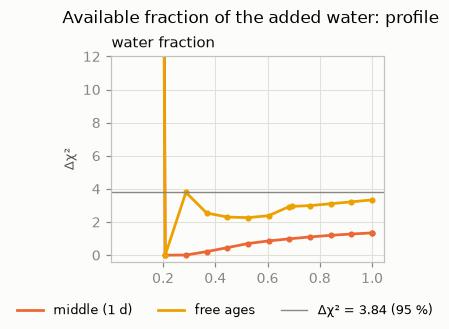

In [14]:
display(read('indistinguishability.csv').set_index(['scenario', 'question']).round(2))
water = {scenario: load_fit_result(str(RESULTS / 'profiles' / f'{MAIN}+W__{scenario}.json')) for scenario in ('middle', 'free')}
display(pd.concat({scenario: w['intervals'].set_index('parameter') for scenario, w in water.items()}).round(2))
fit_plots.plot_profiles({scenario: w['profile'] for scenario, w in water.items()}, ['water fraction'],
                        title='Available fraction of the added water: profile');

**Reading.**
- **Equilibrium or exhausted water: not decided.** Inside M3-split the available fraction of the added water can be anything from 0.2 to 1: χ² changes by at most 1.3 (middle) and 3.8 (free ages) over that range, and the lowest point is at 0.21 in both. That is close to the least the composition of the 2 % sample needs (0.19 if every TMSOH ended as HMDSO), so there the resting state is explained by water running out, and the energy shifts of R2 and R3 fall to 0.08 and 0.13 eV (from 0.15 and 0.21 in the middle scenario). Below 0.2 nothing fits.
- **Exhausted water with the computed energies is not enough.** M1-split with a free water fraction falls from χ² 301 to 82 (middle) and from 282 to 79 (free ages), at a fraction of 0.21, but misses the split between BMSPA and MMSPA in the 2 % sample by 7 SE. It also fails on shares made by M3-split (6.9 SE), so the samples do separate the two structures. The reverse does not hold: M3-split fits shares made by the exhausted-water structure (1.6 SE). It is flexible enough to absorb either explanation.
- **Marcus or Agmon–Levine: no difference** (χ² 20.38 against 20.38, 18.55 against 18.59). The reactions the data see are close to thermoneutral, where the two forms coincide.
- **One hydrolysis barrier or two:** at a common age of one day the samples separate them clearly (16 SE). With free ages they barely do: one barrier reproduces shares made with two at 2.95 SE and misses the lab shares at 3.06 SE. The split of R1 from R2–R3 rests on the assumed ages.

### 5.5 Sensitivity to what was declared

The fit of M3-split repeated with the error floor removed and doubled, the covariance of the computed energies halved and doubled, the ramp of the 2 % sample held 8 h per step instead of the recorded minimum, and the glovebox hold at 4 h and 16 h instead of 8 h. Each variant starts from the main fit with a reduced search; one that fails is fitted again with the full search before it is called a failure (column "search"). The last table repeats two profiles at the tighter solver tolerance.

In [15]:
sensitivities = read('sensitivities.csv')
shown = ['search', 'chi2', 'max |z|', 'worst', 'fits'] + [c for c in sensitivities.columns if c.startswith('dG‡ ') and c.split(' ')[1] in ('R1', 'R2', 'R5', 'R4', 'R8')]
display(sensitivities.set_index(['scenario', 'variant'])[shown].round(3))
read('tolerance_check.csv').round(4)

search    chi2  max |z|  \
scenario variant                                             
middle   as fitted                   full  20.383    1.934   
         floor x0                    full  38.913    3.472   
         floor x2                 reduced  17.737    1.934   
         covariance x0.5          reduced  24.660    2.067   
         covariance x2            reduced  18.191    1.934   
         ramp held 8 h               full  28.666    2.478   
         glovebox 4 h             reduced  20.015    1.934   
         glovebox 16 h            reduced  20.673    1.934   
free     as fitted                   full  18.588    1.934   
         floor x0         full, no better  37.804    3.505   
         floor x2                 reduced  15.645    1.934   
         covariance x0.5          reduced  22.824    2.302   
         covariance x2            reduced  16.394    1.934   
         ramp held 8 h            reduced  18.873    1.932   
         glovebox 4 h             reduced  18.006    1.934   
         glovebox 16 h            reduced  19.028    1.934   

                                                             worst   fits  \
scenario variant                                                            
middle   as fitted                2 % H2O: TMSPA drift, spectrum 4   True   
         floor x0                              TMSOH, probe: TMSOH  False   
         floor x2                 2 % H2O: TMSPA drift, spectrum 4   True   
         covariance x0.5  computed energies: ΔG_rxn(R1) − computed   True   
         covariance x2            2 % H2O: TMSPA drift, spectrum 4   True   
         ramp held 8 h                            0.5 % H2O: BMSPA   True   
         glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   True   
         glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   True   
free     as fitted                2 % H2O: TMSPA drift, spectrum 4   True   
         floor x0                              TMSOH, probe: TMSOH  False   
         floor x2                 2 % H2O: TMSPA drift, spectrum 4   True   
         covariance x0.5  computed energies: ΔG_rxn(R1) − computed   True   
         covariance x2            2 % H2O: TMSPA drift, spectrum 4   True   
         ramp held 8 h            2 % H2O: TMSPA drift, spectrum 4   True   
         glovebox 4 h             2 % H2O: TMSPA drift, spectrum 4   True   
         glovebox 16 h            2 % H2O: TMSPA drift, spectrum 4   True   

                          dG‡ R1  dG‡ R2  dG‡ R5  dG‡ R4  dG‡ R8  
scenario variant                                                  
middle   as fitted         1.449   0.948   0.577   1.241   1.287  
         floor x0          1.452   0.947   0.584   1.239   1.287  
         floor x2          1.450   0.947   0.578   1.241   1.287  
         covariance x0.5   1.448   0.948   0.576   1.240   1.287  
         covariance x2     1.452   0.947   0.585   1.241   1.287  
         ramp held 8 h     1.546   0.924   0.845   1.241   1.287  
         glovebox 4 h      1.452   0.947   0.571   1.218   1.267  
         glovebox 16 h     1.448   0.948   0.583   1.263   1.308  
free     as fitted         1.088   1.037   0.888   1.241   1.287  
         floor x0          1.088   1.038   0.887   1.239   1.287  
         floor x2          1.088   1.037   0.881   1.241   1.287  
         covariance x0.5   1.088   1.037   0.889   1.241   1.287  
         covariance x2     1.088   1.038   0.874   1.241   1.287  
         ramp held 8 h     1.089   1.035   0.858   1.241   1.287  
         glovebox 4 h      1.088   1.038   0.877   1.218   1.266  
         glovebox 16 h     1.088   1.038   0.880   1.263   1.308

,parameter,"low, rtol 1e-6","low, rtol 1e-8","high, rtol 1e-6","high, rtol 1e-8","status, rtol 1e-6","status, rtol 1e-8"
0,g solvent_attack,1.2982,1.2982,1.3255,1.3255,interval,interval
1,g hydrolysis_R23,0.9004,0.9050,0.9784,0.9784,interval,interval


**Reading.**
- **The verdict "fits" needs the declared error floor.** Without it M3-split misses the rule by 3.5 SE in both scenarios, also after the full search: TMSOH in the second spectrum of the probe sample is measured at 0.90 and predicted at 0.99, and noise and baseline alone give that share an error of 0.025. Doubling the floor changes nothing. The barriers are the same in all three cases (within 0.01 eV).
- **The covariance of the computed energies matters little.** Halved or doubled, the fit stays (largest residual 2.1–2.3 SE when halved) and no barrier moves by more than 0.014 eV.
- **Heating steps of 8 h instead of 18 min.** With free ages little changes (χ² 18.9; ΔG‡(R5) lower by 0.03 eV). In the middle scenario the fit survives only with other parameters (χ² 28.7, 2.5 SE): ΔG‡(R5) is 0.85 instead of 0.58 eV and ΔG‡(R1) 1.55 instead of 1.45 eV. The reduced search had missed that solution (3.3 SE). The paper states 8 h per step for this sample, so this may be the real history.
- **Glovebox hold of 4 h or 16 h instead of 8 h.** ΔG‡(R8) and ΔG‡(R4) move by −0.02 and +0.02 eV, which is what a factor of two in time amounts to at 80 °C. The intervals of §5.1 (±0.015 eV for solvent attack) do not include this: they take the 8 h of the paper as given.
- **Solver tolerance.** Two profiles repeated at a relative tolerance of 10⁻⁸: the interval edges move by at most 0.005 eV and the status is the same.

## 6. Checks on data the fit did not use

In [16]:
hold_out = read('hold_out.csv')
display(hold_out[hold_out['structure'] == MAIN].pivot_table(index='quantity', columns='scenario', values='z', sort=False).reindex(columns=list(FITTING)).round(2)
        .rename_axis(columns='tube B: z of the prediction'))
alone = read('check_tmspa_alone.csv')
display(alone[(alone['structure'] == MAIN) & alone['scenario'].isin(FITTING)].set_index(['scenario', 'parameters', 'co-products'])[['water_mM', 'max |z|']].unstack('co-products', sort=False).round(1)
        .rename_axis(index=['scenario', 'TMSPa alone: parameters'], columns=[None, 'silyl groups already released, present as']))
paper = read('check_paper.csv')
paper[paper['structure'] == MAIN].pivot_table(index=['observation', 'age'], columns='scenario', values='agrees', aggfunc='first', sort=False).reindex(columns=list(FITTING))

tube B: z of the prediction,middle,long,free
quantity,,,
TMSPA,0.03,0.31,0.24
BMSPA,-1.23,-1.15,-1.18
MMSPA,2.60,2.13,2.24
H3PO4,-0.23,-0.27,-0.24


water_mM              max |z|        \
silyl groups already released, present as     none TMSOH  HMDSO    none TMSOH   
scenario TMSPa alone: parameters                                                
middle   the fit                              38.3  14.3   38.4     0.8   0.8   
         fitted with TMSOH 1uM at mixing      43.3  14.4   39.5     1.6   0.8   
         fitted with TMSOH 1mM at mixing      38.2  12.8   37.0     0.8   0.8   
long     the fit                              41.2  16.1   41.8     0.8   0.8   
         fitted with TMSOH 1uM at mixing      39.9  14.0   39.9     0.8   0.8   
         fitted with TMSOH 1mM at mixing      86.1  22.5   75.7     0.8   0.8   
free     the fit                             139.5  39.1  134.1     6.0   3.9   
         fitted with TMSOH 1uM at mixing     139.5  39.1  134.1     6.0   3.9   
         fitted with TMSOH 1mM at mixing     146.1  39.7  140.3     6.1   4.0   

                                                 
silyl groups already released, present as HMDSO  
scenario TMSPa alone: parameters                 
middle   the fit                            0.8  
         fitted with TMSOH 1uM at mixing    0.9  
         fitted with TMSOH 1mM at mixing    0.8  
long     the fit                            0.8  
         fitted with TMSOH 1uM at mixing    0.8  
         fitted with TMSOH 1mM at mixing    0.8  
free     the fit                            5.6  
         fitted with TMSOH 1uM at mixing    5.6  
         fitted with TMSOH 1mM at mixing    5.8

scenario                    middle   long   free
observation age                                 
E4          24 h (assumed)   False  False  False
W1          1 h               True   True   True
            1 d              False   True   True
            7 d              False  False  False
W5          1 h              False  False  False
            1 d              False  False  False
            7 d              False   True  False

**Reading.**
- **Tube B (hold-out) is not contradicted, and says little.** The largest residual is 2.1–2.6 SE in the three scenarios that fit. The model gives tube B the composition of tube A (same recipe, transfer at equilibrium), with 17–21 % MMSPA where tube B shows 1 ± 8 %. Its 16-scan spectrum has errors up to 0.18.
- **TMSPa without added water separates the fits.** The common-age fits turn its first spectrum into its second, 243 h later, within 0.8 SE, and so do the same scenarios fitted with a trace of TMSOH (at most 1.6 SE). The water this takes is 13–86 mM (200–1 350 ppm), depending on the fit and on where the silyl groups already released at the first spectrum are taken to be. The free-age fit cannot do it at any water content: it misses by 3.9–6.1 SE, because its three hydrolysis barriers are too close for 69 % of the phosphate to rest at BMSPA.
- **Paper, TMSPA + TMSOH (E4):** predicted conversion 0.88–0.93, where "no TMSPA detectable" was read as at least 0.95. The lab's own tube A, same recipe, shows 0.90 ± 0.05, and the fit follows it.
- **Paper, water series:** at 1 vol% water the paper reports that the reaction stops at BMSPA with most TMSPA unreacted. Every fit agrees only while the reaction has not started (up to 1 h or 1 day) and predicts no TMSPA after a week (MMSPA 0.41–0.45, H₃PO₄ 0.47–0.51). At 5 vol% the fits end at H₃PO₄ 0.77–0.83 against a reading of at least 0.8. The paper does not state the time between mixing and spectrum.
- **No fit passes every check.** The common-age fits pass TMSPa alone and depend on a trace (§4.3). The free-age fit does not depend on a trace and fails TMSPa alone. None gives a 1 % water sample that stays at BMSPA.

## 7. Predictions

### 7.1 Storage at 25 °C

The sealed electrolyte of notebook 01 (50 mM TMSPA, 20 mM water, 4.5 M EC): time to consume 90 % of the water. The band is the range over the best fit and every profile point inside the 95 % intervals.

In [17]:
storage = read('prediction_storage.csv')
days = storage.assign(**{'best fit (days)': storage['t90 water (h), best fit'] / 24, 'accepted sets, from (days)': storage['band low (h)'] / 24,
                         'to (days)': storage['band high (h)'] / 24})
display(days[days['scenario'].isin(FITTING)].set_index(['structure', 'scenario'])[
    ['best fit (days)', 'accepted sets, from (days)', 'to (days)', 'accepted sets', 'TMSPA left after 1 year, best fit']].round(
    {'best fit (days)': 0, 'accepted sets, from (days)': 0, 'to (days)': 0, 'TMSPA left after 1 year, best fit': 2})
        .rename_axis('time to consume 90 % of the water', axis=1))
seeded = read('prediction_storage_traces.csv')
seeded = seeded[seeded['scenario'].isin(FITTING)].assign(**{'TMSOH at mixing': seeded['TMSOH at mixing (M)'].map(show_M)})
(seeded.set_index(['scenario', 'TMSOH at mixing'])[[c for c in seeded.columns if c.startswith('t90')]] / 24).round(0).rename(
    columns=lambda c: c.replace('t90 water (h), ', '')).rename_axis('days to consume 90 % of the water', axis=1)

time to consume 90 % of the water  best fit (days)  \
structure scenario                                   
M3-split  middle                              17.0   
          long                                89.0   
          free                                84.0   
M1        middle                              33.0   
          long                               233.0   
          free                               149.0   

time to consume 90 % of the water  accepted sets, from (days)  to (days)  \
structure scenario                                                         
M3-split  middle                                         17.0       23.0   
          long                                           72.0      176.0   
          free                                           18.0      100.0   
M1        middle                                         28.0       35.0   
          long                                          231.0      233.0   
          free                                          125.0      209.0   

time to consume 90 % of the water  accepted sets  \
structure scenario                                 
M3-split  middle                              70   
          long                                86   
          free                                89   
M1        middle                              25   
          long                                15   
          free                                26   

time to consume 90 % of the water  TMSPA left after 1 year, best fit  
structure scenario                                                    
M3-split  middle                                                0.27  
          long                                                  0.28  
          free                                                  0.26  
M1        middle                                                0.20  
          long                                                  0.20  
          free                                                  0.20

days to consume 90 % of the water  no trace  fit as it is  \
scenario TMSOH at mixing                                    
middle   1 µM                          17.0           7.0   
         1 mM                          17.0           3.0   
long     1 µM                          89.0          64.0   
         1 mM                          89.0          29.0   
free     1 µM                          84.0          84.0   
         1 mM                          84.0          81.0   

days to consume 90 % of the water  fitted with the trace  
scenario TMSOH at mixing                                  
middle   1 µM                                       20.0  
         1 mM                                       18.0  
long     1 µM                                       74.0  
         1 mM                                      111.0  
free     1 µM                                       84.0  
         1 mM                                       86.0

**Reading.**
- **Best fits: 90 % of the water is gone after 17 days (middle), 89 days (long) or 84 days (free ages).** Over the accepted parameter sets: 17–23, 72–176 and 18–100 days. Together that is between 2½ weeks and 6 months, a factor of ten.
- **The common-age numbers move with a trace of TMSOH** (second table). The middle fit gives 17 days from the recipe alone, 7 days with 1 µM and 3 days with 1 mM; fitted again with the trace in place it gives 18–20 days. The long fit gives 89, 64 and 29 days; fitted again, 74 and 111 days. The free-age fit stays at 81–86 days in every case.
- **After one year about a quarter of the TMSPA is left in every scenario (0.26–0.28).** This is set by the amount of water (20 mM for 50 mM TMSPA) and the fitted energies, not by the barriers, and is the most stable number here.
- **M1 is listed for comparison only:** it fits no scenario (§4). Its numbers, 1 to 8 months, show how far the answer moves with the structure.
- **What the prediction rests on:** barriers seen at 22 °C in two water samples of unknown age, applied at 25 °C to a recipe with 13 to 50 times less water. The step in water content is as untested as the ages.

### 7.2 Peter's protocol and the temperature blind spot

Every barrier of hydrolysis and transfer is measured at 22 °C only, and the protocol runs up to 80 °C. The fit fixes ΔS‡ = 0; here the best fit is rerun with ΔS‡ from −150 to +50 J mol⁻¹ K⁻¹ for every family, each barrier anchored at the temperature where it was observed.

hold T (°C)             20.0   30.0   40.0   50.0   60.0   70.0   80.0
scenario dS (J/mol/K)                                                 
free     -150.0        0.899  0.620  0.089  0.000  0.000  0.000  0.000
         -100.0        0.904  0.581  0.015  0.000  0.000  0.000  0.000
         -50.0         0.910  0.535  0.001  0.000  0.000  0.000  0.000
          0.0          0.915  0.479  0.000  0.000  0.000  0.000  0.000
          50.0         0.920  0.414  0.000  0.000  0.000  0.000  0.000
long     -150.0        1.000  1.000  0.953  0.000  0.000  0.000  0.000
         -100.0        1.000  1.000  0.033  0.000  0.000  0.000  0.000
         -50.0         1.000  1.000  0.001  0.000  0.000  0.000  0.000
          0.0          1.000  1.000  0.000  0.000  0.000  0.000  0.000
          50.0         1.000  1.000  0.000  0.000  0.000  0.000  0.000
middle   -150.0        1.000  0.000  0.000  0.000  0.000  0.000  0.000
         -100.0        1.000  0.000  0.000  0.000  0.000  0.000  0.000
         -50.0         1.000  0.000  0.000  0.000  0.000  0.000  0.000
          0.0          1.000  0.000  0.000  0.000  0.000  0.000  0.000
          50.0         1.000  0.000  0.000  0.000  0.000  0.000  0.000
short    -150.0        0.130  0.130  0.130  0.129  0.129  0.127  0.124
         -100.0        0.130  0.130  0.130  0.129  0.129  0.128  0.124
         -50.0         0.130  0.130  0.130  0.130  0.129  0.128  0.125
          0.0          0.130  0.130  0.130  0.130  0.129  0.128  0.125
          50.0         0.130  0.130  0.130  0.130  0.129  0.129  0.125

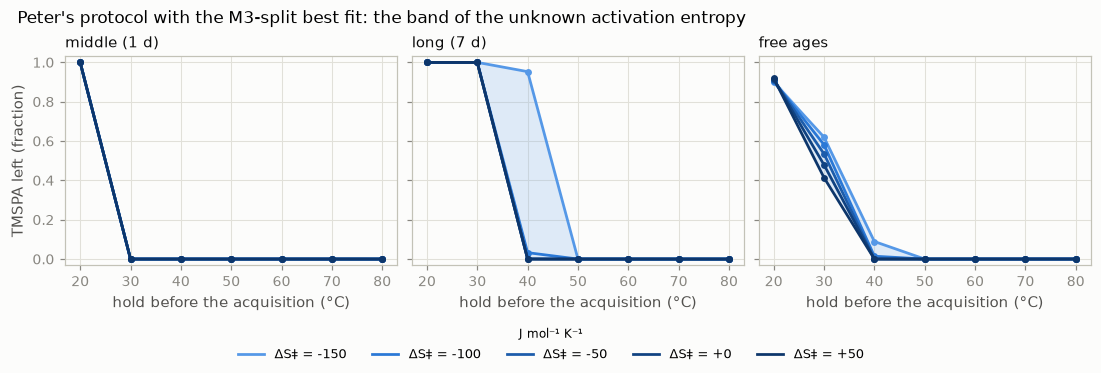

In [18]:
protocol = read('prediction_protocol.csv')
fit_plots.plot_protocol_band(protocol, structure=MAIN, scenarios=('middle', 'long', 'free'));
protocol[protocol['structure'] == MAIN].pivot_table(index=['scenario', 'dS (J/mol/K)'], columns='hold T (°C)', values='TMSPA left').round(3)

**Reading.**
- **The scenario decides the prediction, not the activation entropy.** In the middle fit all TMSPA is still there at the 20 °C acquisition and none at 30 °C, for every ΔS‡: the cliff of §4.3 falls between them. In the long fit all TMSPA survives 20 and 30 °C and is gone at 50 °C; ΔS‡ only decides the 40 °C point (0.95 left at −150 J mol⁻¹ K⁻¹, 0.03 at −100, none above). With free ages 0.90–0.92 is left at 20 °C, 0.41–0.62 at 30 °C and 0–0.09 at 40 °C.
- **The band of ΔS‡ is narrow because TMSPA is gone close to where the barriers were measured.** All three fits consume it by 40–50 °C, within 20–30 K of the 22 °C at which hydrolysis and transfer were seen. Over that range ΔS‡ between −150 and +50 J mol⁻¹ K⁻¹ changes a barrier by at most 0.03–0.05 eV.
- **The temperature blind spot is elsewhere.** At the 60–80 °C holds the fits act only through condensation and solvent attack (measured at 80 °C) on a mixture that has already reacted. Hydrolysis and transfer at 60–80 °C are never tested.
- **What would narrow it:** one sample followed in time at 22 °C from a known mixing time, which removes the age and the trace as unknowns, and the same recipe at a second temperature, which measures ΔS‡.
- **Against `peter_reference`:** 1.15 eV spreads the consumption of TMSPA over the 20–80 °C holds by construction. No fit here does: each consumes it within one or two holds.

## 8. What is still open

**What the data say in every scenario, with or without a trace, and under every variant of §5.5**
- Solvent attack: ΔG‡(R8) = 1.29 eV at 80 °C (1.28–1.30; ±0.02 more if the glovebox hold was 4 h or 16 h).
- Condensation: ΔG‡(R4) = 1.24 eV at 80 °C (1.22–1.28, same remark).
- Second and third hydrolysis: ΔG‡(R2) = 0.92–1.05 eV and ΔG‡(R3) = 0.94–1.07 eV at 22 °C.
- ΔG_rxn of R2 and R3 lies above the computed values (by +0.08 to +0.48 eV with all the water available).
- No single barrier, and no barrier per family with the computed energies, describes the samples.

**What they do not say**
1. How TMSPA is consumed. ΔG‡(R1) between 1.08 and 1.65 eV and ΔG‡(R5) between 0.41 and 0.99 eV are all accepted; the ages and the TMSOH present at mixing decide.
2. Whether the 2 % sample rests at an equilibrium or ran out of water: any available fraction from 0.2 to 1 fits.
3. The temperature dependence of hydrolysis and transfer: seen at 22 °C only.
4. The shape of the barrier relation (Marcus or Agmon–Levine).
5. Whether any barrier except solvent attack is right: each of the others rests on one spectrum.

**Decisions left to the author**
- *A fitted model in the registry.* By the rule fixed before fitting, the first consistent set is M3-split at a common age: the long scenario (χ² 19.8) by the lower χ², the middle one (20.4) just behind. Nothing was written into the registry, because both rest on the induction time of §4.3 and the free-age set fails TMSPa alone (§6). `build_fitted_model` builds any of them from its result file.
- *Storing the lab-derived files.* `data/lab_observables.json` and `notebooks/results/05/` are not in the repository.

**Audit that needs the raw spectra**
- The ³¹P region near −144 ppm (PF₆⁻) in every TMSPa sample, not only the 0.5 % one.
- The ¹⁹F spectrum of the glovebox TMSOH sample.
- The clock times and durations of the heating steps of the 2 % sample (18 min assumed, 8 h stated in the paper; §5.5 shows what changes).

**Left for later**
- TMSPa without added water as a fitted sample, with its water content as a parameter: §6 shows that it separates the fits.
- Rate-law variants, condensation from ¹H, sampling of the parameter space, gas evolution at 60–80 °C.